## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





In [617]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random as rd

In [618]:
def simulazione_lanci(N):
    lanci=[np.random.randint(0,2) for i in range(N)]
    return (sum(lanci)/N)*100

In [619]:
def funzione (vec_prob, n):
    campione = np.random.choice(a=[0,1], size=n, replace=True, p=vec_prob)
    return sum(campione)

In [620]:
def simulazione_lanci(N):
    lanci=[rd.randint(0,1) for i in range(N)]
    return (sum(lanci)/N)*100
campioni=[n for n in range(10,20001, int(20000/100))]
risultati_campioni=[simulazione_lanci(n) for n in campioni]
ls_risultati=[[campioni[i],risultati_campioni[i]] for i in range(len(campioni))]
df=pd.DataFrame(ls_risultati)


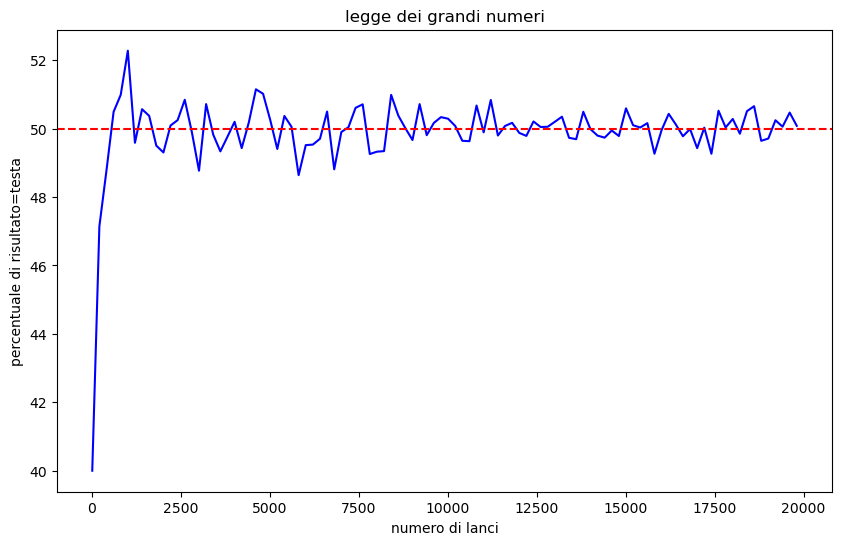

In [621]:

plt.figure(figsize=(10,6))
sns.lineplot(data=df, x=df[0], y=df[1], color="blue")
plt.axhline(50, color='red', linestyle='--')
plt.xlabel("numero di lanci")
plt.ylabel("percentuale di risultato=testa")
plt.title("legge dei grandi numeri")
plt.show()

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

Righe e colonne dataset:  (891, 12)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Check colonna Embarked:  0

Dataset non ha duplicati
Età media per classe: 
 Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64



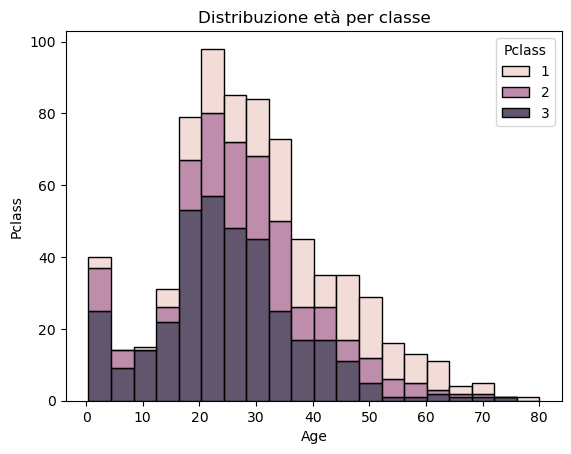

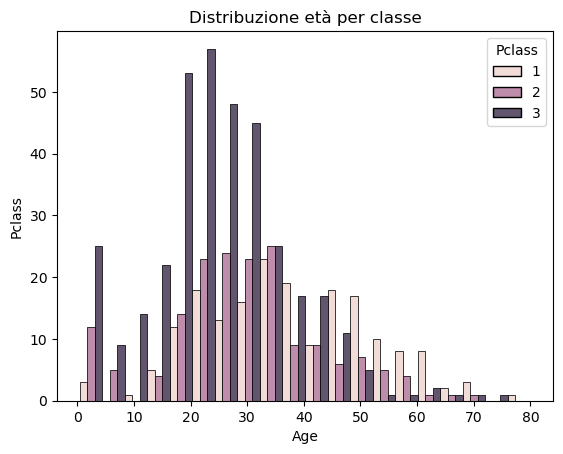

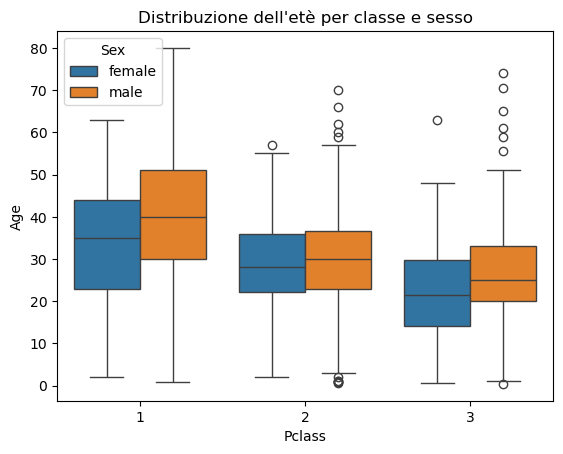

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

#1
print("Righe e colonne dataset: ", df.shape)
print()

#2 valori NaN per colonna
print(df.isna().sum())
print()

#3 fillna "Embarked" con moda in colonna "Embarked"
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
print("Check colonna Embarked: ", df["Embarked"].isna().sum())
print()

#4 check righe duplicate
df_no_d = df.drop_duplicates()
if df.shape == df_no_d.shape:
    print("Dataset non ha duplicati")
else:
    print("Ci sono duplicati")

#5 Calcola l'età media dei passeggeri per ogni classe (Pclass), se ci sono valori mancanti di età riempili con il valore medio
df_Age_m = df.groupby("Pclass")["Age"].mean()
print("Età media per classe: \n", df_Age_m)
df.loc[(df["Pclass"] == 1) & (df["Age".isna()])]


print()

#6 distribuzione età per classe
sns.histplot(data=df,
             x="Age",
             hue="Pclass",
             multiple="stack")
plt.title("Distribuzione età per classe")
plt.xlabel("Age")
plt.ylabel("Pclass")
plt.show()

#6 
sns.histplot(data=df,
             x="Age",
             hue="Pclass",
             multiple="dodge"
             )
plt.title("Distribuzione età per classe")
plt.xlabel("Age")
plt.ylabel("Pclass")
plt.show()

#7 distribuzione età per classe dividendo e mostrando insieme i dati di uomini e donne
sns.boxplot(data=df,
            y="Age",
            x="Pclass",
            hue="Sex")
plt.title("Distribuzione dell'etè per classe e sesso")
plt.show()

df.head()

## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

Campioni per specie:  species
setosa        50
versicolor    50
virginica     50
dtype: int64

Lunghezza e larghezza media per specie: 
             petal_length  petal_width
species                              
setosa             1.462        0.246
versicolor         4.260        1.326
virginica          5.552        2.026



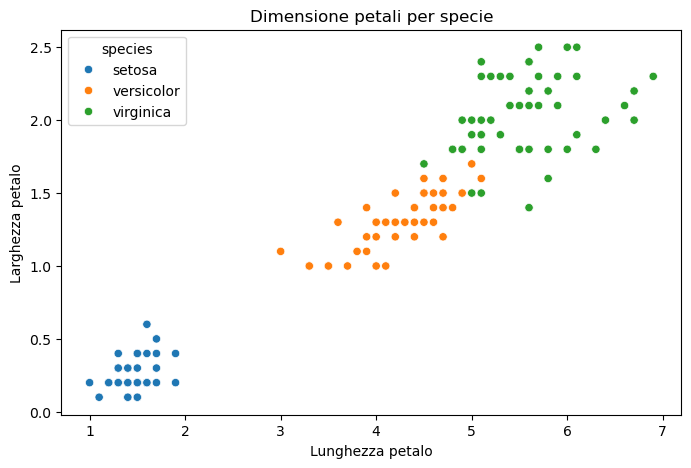

Area media del petalo per specie: 
 species
setosa         0.3656
versicolor     5.7204
virginica     11.2962
Name: petal_area, dtype: float64


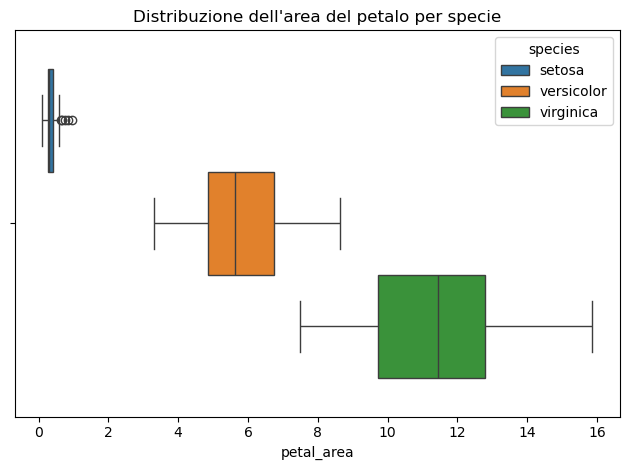

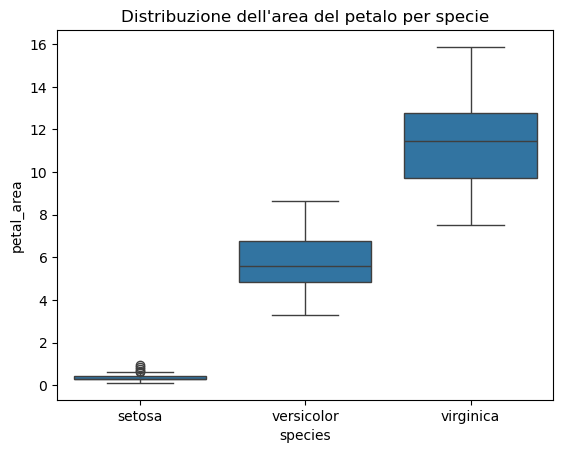

,sepal_length,sepal_width,petal_length,petal_width,species,petal_area
0,5.1,3.5,1.4,0.2,setosa,0.28
1,4.9,3.0,1.4,0.2,setosa,0.28
2,4.7,3.2,1.3,0.2,setosa,0.26
3,4.6,3.1,1.5,0.2,setosa,0.30
4,5.0,3.6,1.4,0.2,setosa,0.28


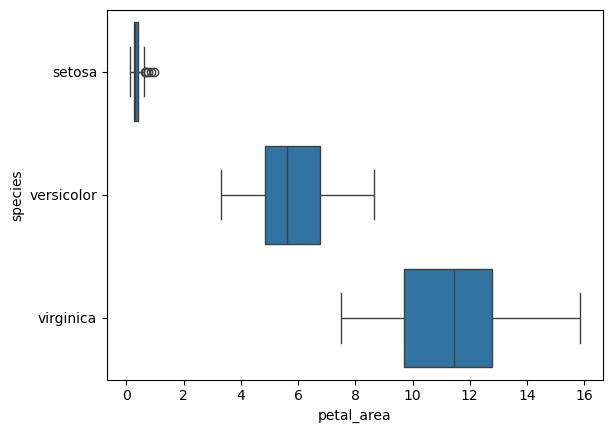

In [623]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

#1
print("Campioni per specie: ", df.groupby("species").size())
print()

#2
print("Lunghezza e larghezza media per specie: \n", df.groupby("species")[["petal_length", "petal_width"]].mean())
print()

#3 Dimensione dei petali per specie
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="petal_length",
    y="petal_width",
    hue="species"
)

plt.title("Dimensione petali per specie")
plt.xlabel("Lunghezza petalo")
plt.ylabel("Larghezza petalo")
plt.show()

#4
df["petal_area"] = df["petal_length"]*df["petal_width"]
print("Area media del petalo per specie: \n", df.groupby("species")["petal_area"].mean())

#5
sns.boxplot(data=df,
            x="petal_area",
            hue="species")
plt.title("Distribuzione dell'area del petalo per specie")
plt.tight_layout()
plt.show()

#5 verticale
sns.boxplot(
    data=df,
    x="species",
    y="petal_area"
)
plt.title("Distribuzione dell'area del petalo per specie")
plt.show()

#5 orizzontale
sns.boxplot(
    data=df,
    x="petal_area",
    y="species"
)

df.head()